# Shared block weight explorer

Summarize and histogram **every weight/bias tensor** in the single shared ConvNeXt block used in stage 3 after `rewire()`.

Layout: `dw conv → LayerNorm2d → pw1 → GELU → pw2 → LayerScale`

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().resolve().parent))

import matplotlib.pyplot as plt
import torch

from models.backbones.delta_convnext import DeltaConvNext
from models.blocks.deltaBlock import DeltaConvnextBlock

MODEL_PATH = Path(
    "/home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/outputs/shared_convnextv1_imagenet/weights/last.pth"
)

LAYER_NAMES = ("dw", "ln", "pw1", "gelu", "pw2", "ls")


def load_shared_convnext(checkpoint: Path) -> DeltaConvNext:
    model = DeltaConvNext(useDeltas=False)
    model.rewire()
    ckpt = torch.load(checkpoint, map_location="cpu")
    state_dict = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
    model.load_state_dict(state_dict, strict=True)
    epoch = ckpt.get("epoch") if isinstance(ckpt, dict) else None
    print(f"Loaded {checkpoint}" + (f" (epoch {epoch})" if epoch is not None else ""))
    return model


model = load_shared_convnext(MODEL_PATH)
model.eval()

shared_layers = dict(zip(LAYER_NAMES, model.sharedBlock))
shared_weights = DeltaConvnextBlock.sharedWeights(model.sharedBlock)
print("Shared block tensors:")
for name, tensor in shared_weights:
    print(f"  {name:10s}  shape={tuple(tensor.shape)}  params={tensor.numel():,}")

Rewired: stage3 -> 1 shared block + shared-only (no delta params) + 2 tail layers
Loaded /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/outputs/shared_convnextv1_imagenet/weights/last.pth (epoch 299)
Shared block tensors:
  dw.weight   shape=(384, 1, 7, 7)  params=18,816
  ln.weight   shape=(384,)  params=384
  pw1.weight  shape=(1536, 384, 1, 1)  params=589,824
  pw2.weight  shape=(384, 1536, 1, 1)  params=589,824
  ls.gamma    shape=(384,)  params=384
  dw.bias     shape=(384,)  params=384
  ln.bias     shape=(384,)  params=384
  pw1.bias    shape=(1536,)  params=1,536
  pw2.bias    shape=(384,)  params=384


## Summary table

All 9 learnable tensors (`GELU` has none): shape, min, max, mean, std, L2 norm.

In [2]:
import pandas as pd

rows = []
for name, tensor in shared_weights:
    flat = tensor.detach().float().cpu().reshape(-1)
    rows.append(
        {
            "tensor": name,
            "shape": str(tuple(tensor.shape)),
            "params": tensor.numel(),
            "min": flat.min().item(),
            "max": flat.max().item(),
            "mean": flat.mean().item(),
            "std": flat.std().item(),
            "L2": flat.norm().item(),
        }
    )

summary_df = pd.DataFrame(rows).set_index("tensor")
summary_df.style.format({"min": "{:.4f}", "max": "{:.4f}", "mean": "{:.4f}", "std": "{:.4f}", "L2": "{:.2f}"})

,shape,params,min,max,mean,std,L2
tensor,,,,,,,
dw.weight,"(384, 1, 7, 7)",18816,-0.4172,0.4277,-0.0002,0.0447,6.12
ln.weight,"(384,)",384,0.0398,2.6326,1.1545,0.3633,23.72
pw1.weight,"(1536, 384, 1, 1)",589824,-0.4862,0.4269,-0.0011,0.0478,36.75
pw2.weight,"(384, 1536, 1, 1)",589824,-0.8278,0.8122,-0.0002,0.0470,36.08
ls.gamma,"(384,)",384,-5.5785,2.3187,-0.0008,0.6992,13.68
dw.bias,"(384,)",384,-3.6472,1.6125,-0.0114,0.2415,4.73
ln.bias,"(384,)",384,-0.9407,2.3910,-0.0067,0.2811,5.50
pw1.bias,"(1536,)",1536,-1.7579,0.8326,-0.6196,0.2930,26.86
pw2.bias,"(384,)",384,-3.9723,0.4740,-0.0156,0.2393,4.69


## Per-layer histograms

One histogram per tensor, grouped by block layer (`dw`, `ln`, `pw1`, `pw2`, `ls`).


Layer: dw (Conv2d)
dw.weight
  shape=(384, 1, 7, 7)
  min=-0.417164  max=0.427709  mean=-0.000207  std=0.044651  L2=6.124801


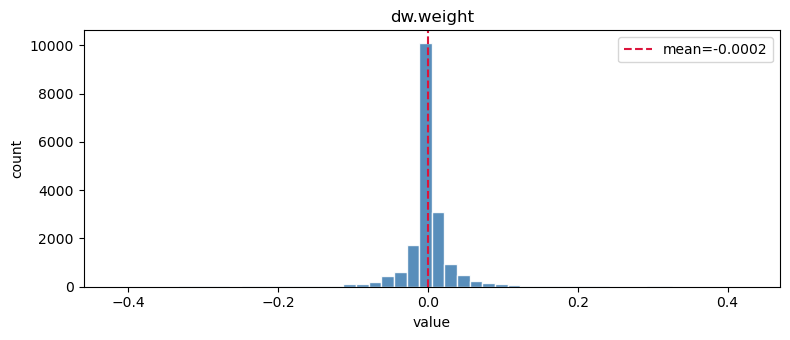

dw.bias
  shape=(384,)
  min=-3.647179  max=1.612468  mean=-0.011399  std=0.241468  L2=4.730908


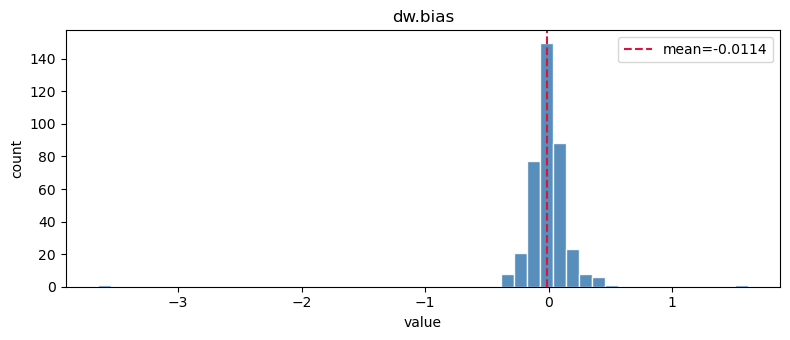


Layer: ln (LayerNorm2d)
ln.weight
  shape=(384,)
  min=0.039816  max=2.632566  mean=1.154531  std=0.363315  L2=23.715063


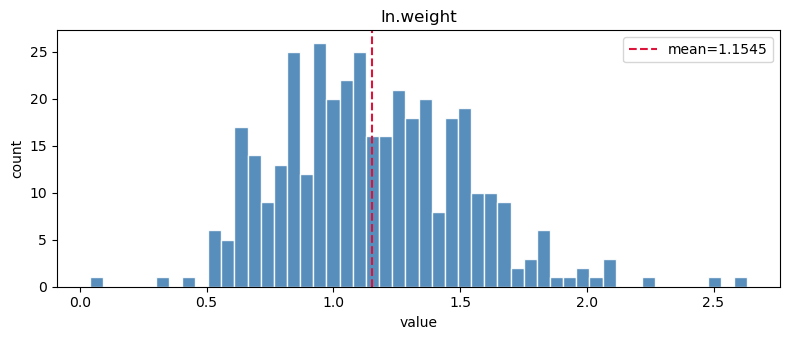

ln.bias
  shape=(384,)
  min=-0.940748  max=2.391002  mean=-0.006720  std=0.281135  L2=5.503498


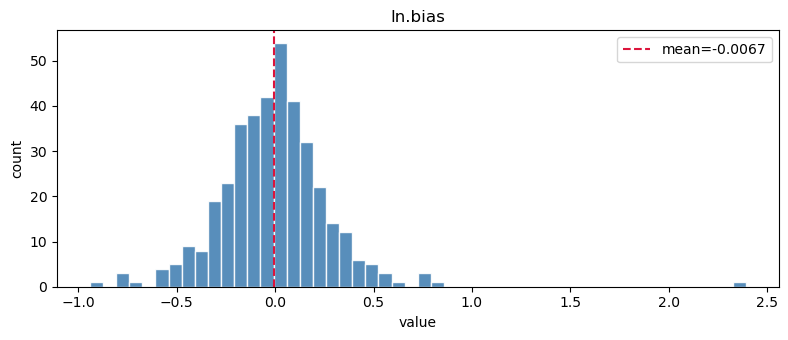


Layer: pw1 (Conv2d)
pw1.weight
  shape=(1536, 384, 1, 1)
  min=-0.486235  max=0.426919  mean=-0.001058  std=0.047846  L2=36.754478


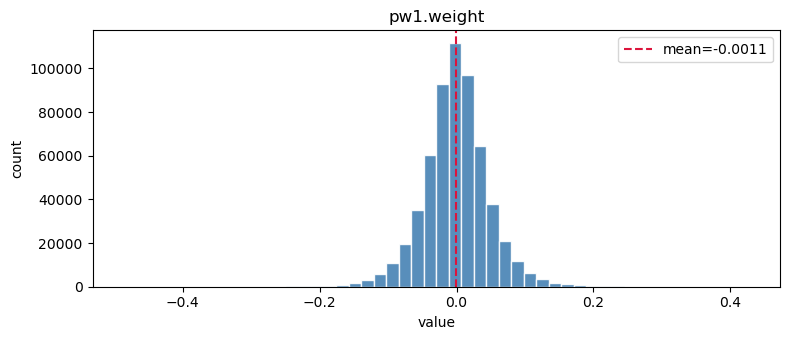

pw1.bias
  shape=(1536,)
  min=-1.757900  max=0.832628  mean=-0.619578  std=0.292999  L2=26.859131


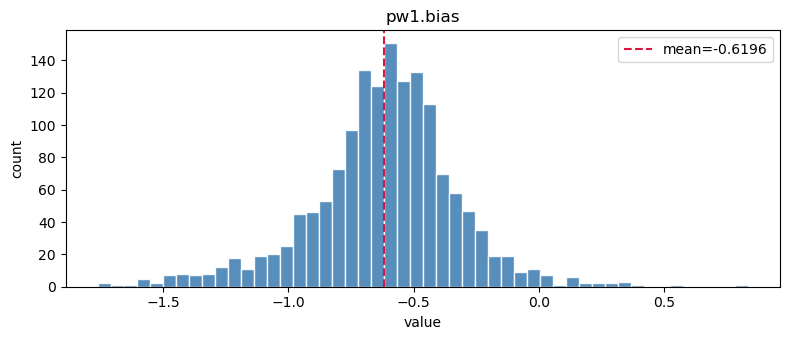


Layer: gelu (GELU)
  (no learnable weights)

Layer: pw2 (Conv2d)
pw2.weight
  shape=(384, 1536, 1, 1)
  min=-0.827830  max=0.812157  mean=-0.000236  std=0.046980  L2=36.080433


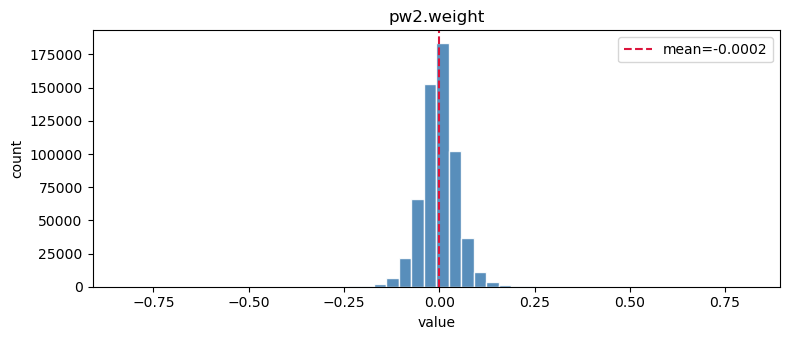

pw2.bias
  shape=(384,)
  min=-3.972294  max=0.474015  mean=-0.015632  std=0.239272  L2=4.692662


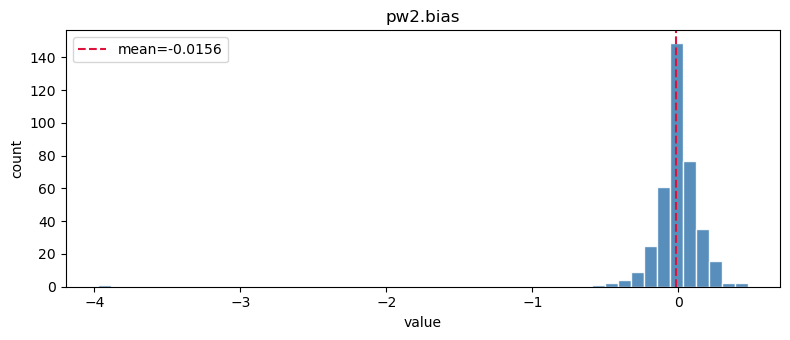


Layer: ls (LayerScale)
ls.gamma
  shape=(384,)
  min=-5.578482  max=2.318736  mean=-0.000822  std=0.699230  L2=13.684211


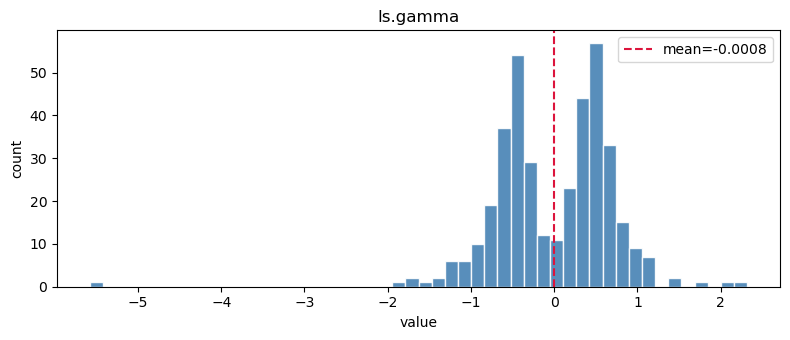

In [3]:
def summarize_tensor(name: str, x: torch.Tensor) -> torch.Tensor:
    """Print stats and return a flat CPU copy for plotting."""
    flat = x.detach().float().cpu().reshape(-1)
    print(f"{name}")
    print(f"  shape={tuple(x.shape)}")
    print(
        f"  min={flat.min():.6f}  max={flat.max():.6f}  "
        f"mean={flat.mean():.6f}  std={flat.std():.6f}  L2={flat.norm():.6f}"
    )
    return flat


def plot_histogram(name: str, values: torch.Tensor, *, bins: int = 50) -> None:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(values.numpy(), bins=bins, color="steelblue", edgecolor="white", alpha=0.9)
    ax.set_title(name)
    ax.set_xlabel("value")
    ax.set_ylabel("count")
    ax.axvline(
        values.mean().item(),
        color="crimson",
        linestyle="--",
        linewidth=1.5,
        label=f"mean={values.mean():.4f}",
    )
    ax.legend()
    fig.tight_layout()
    plt.show()


for layer_name in LAYER_NAMES:
    layer = shared_layers[layer_name]
    print(f"\n{'=' * 72}")
    print(f"Layer: {layer_name} ({type(layer).__name__})")
    print("=" * 72)

    if layer_name == "gelu":
        print("  (no learnable weights)")
        continue

    if layer_name == "ls":
        tensors = [("ls.gamma", layer.gamma)]
    else:
        tensors = [(f"{layer_name}.weight", layer.weight), (f"{layer_name}.bias", layer.bias)]

    for tensor_name, tensor in tensors:
        flat = summarize_tensor(tensor_name, tensor)
        plot_histogram(tensor_name, flat)

## Overview grid

All 9 histograms in a single figure.

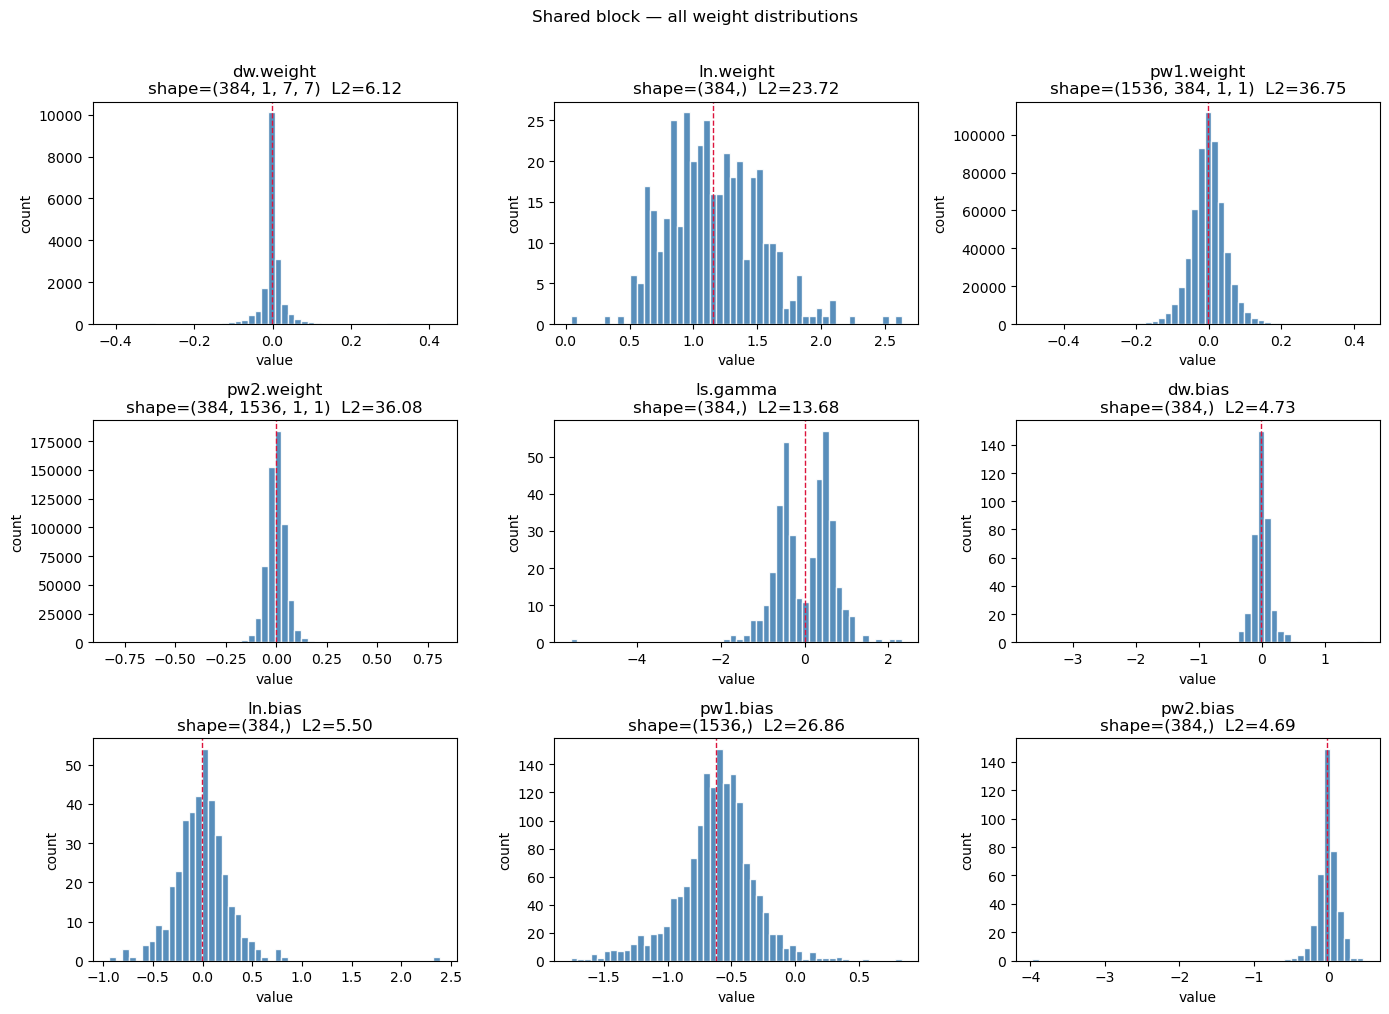

In [4]:
# Optional: all histograms in one figure for a quick overview
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()

for ax, (name, tensor) in zip(axes, shared_weights):
    flat = tensor.detach().float().cpu().reshape(-1)
    ax.hist(flat.numpy(), bins=50, color="steelblue", edgecolor="white", alpha=0.9)
    ax.axvline(flat.mean().item(), color="crimson", linestyle="--", linewidth=1)
    ax.set_title(f"{name}\nshape={tuple(tensor.shape)}  L2={flat.norm():.2f}")
    ax.set_xlabel("value")
    ax.set_ylabel("count")

for ax in axes[len(shared_weights):]:
    ax.axis("off")

fig.suptitle("Shared block — all weight distributions", y=1.01)
fig.tight_layout()
plt.show()